## The Paleobiology Database

## Lab Three: Extending Logistic Regression

### Gavin Bovone, Matthew Benedict
## https://paleobiodb.org/#/

## Business Understanding

The dataset we selected contains fossil discoveries across the world, including the type of fossil, its geologic formation, and the geographic location where it was found. These records are organized “by a multi-disciplinary, multi-institutional, international group of paleobiological researchers”. The purpose of this dataset is “to provide global, collection-based occurrence and taxonomic data for organisms of all geological ages” for which they created a public, interactive data map to educate the public on the history of life around the world.

Although the full dataset spans all kinds of fossils worldwide with over a million records, the prediction task for this project is to predict the correct age of a dinosaur fossil based on the aforementioned data collected, specifically for all of the fossils found in or around Texas. According to the American Museum of Natural History, there are many different methods to determine the estimated age of fossils, including sediment analysis. However, creating a prediction model based on geographic, sedimentary, and biological information could speed up the process of fossil dating. This is important because the age of a fossil is often difficult to determine in the field, and being able to automatically predict the time period based on the characteristics of the fossil could speed up research and improve accuracy.

### Measure of Success

Next, we have to determine what the required success of this algorithm must look like for it to be considered successful. 
The third party who would be most interested in these predictions are paleontologists for dating and categorizing fossils more efficiently. As mentioned above, correcly dating the age of a fossil is a long and difficult process, but if paleontologists had a prediction model available it would greatly speed up the process and save both time and resources.  With paelontogy being focused in the scientific field, they require higher standards of success. Therefore, we would want our model to at least achieve the minimum accuracy rate accepted by professionals as misclassifying a fossil’s time period could mislead scientific research and public understanding.

The research paper, [Fossil image identification using deep learning ensembles of data augmented multiviews](https://besjournals.onlinelibrary.wiley.com/doi/full/10.1111/2041-210X.14229), which is published in The British Ecological Society created a similar model based on visual data. According to the study, the expert success in this type of prediction is in the range of 63%-85%, with their model achieving a peak success rate of 87.4%. This data shows an accuracy rate of 63% is still valuable, meaning a model with slightly lower accuracy could still be valuable as a decision-support tool, helping researchers prioritize which fossils to send for further expert analysis. The visual model was able to achieve a higher rate of accuracy than professional standards, showing improvements can still be made in fossil-dating technology. Based on this, we should expect an accuracy somewhere in the range of 75%-90% so as to meet the basic scientific standards while still trying to make improvements in the field.


# Loading The Dataset

In [1]:
# Loading the dataset identical to Lab 1
import pandas as pd
import numpy as np

print('Pandas:', pd.__version__)
print('Numpy:',np.__version__)

#df = pd.read_csv("./pbdb_data-no-metadata.csv")
df = pd.read_csv("./glorious_data_no_metadata.csv")
df.head()

Pandas: 2.3.2
Numpy: 2.3.2


/var/folders/lv/75_7qmqd7mg3hzftqx8f9ttc0000gn/T/ipykernel_92402/1681135331.py:9: DtypeWarning: Columns (26,41,44,45,46,47,58,59,69,70,87) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./glorious_data_no_metadata.csv")


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,modifier,updater,created,modified,updated,paleomodel,geoplate,paleoage,paleolng,paleolat
0,1,occ,NaN,NaN,1,Australosutura llanoensis,species,349412,NaN,Australosutura llanoensis,...,M. Clapham,NaN,1998-11-20 07:59:51,2018-02-02 16:22:36,NaN,gplates,101,mid,-65.70,-26.70
1,2,occ,NaN,NaN,1,Carbonocoryphe planucauda,species,349526,recombined as,Phillibole planucauda,...,M. Clapham,NaN,1998-11-20 07:59:51,2018-02-02 16:22:36,NaN,gplates,101,mid,-65.70,-26.70
2,3,occ,NaN,NaN,1,Thigriffides roundyi,species,349420,NaN,Thigriffides roundyi,...,M. Clapham,NaN,1998-11-20 07:59:51,2018-02-02 16:22:36,NaN,gplates,101,mid,-65.70,-26.70
3,4,occ,NaN,NaN,2,Pudoproetus chappelensis,species,349411,NaN,Pudoproetus chappelensis,...,NaN,NaN,2001-03-26 11:06:31,2000-11-30 12:09:35,NaN,gplates,101,mid,-65.59,-27.46
4,5,occ,NaN,NaN,3,Pudoproetus chappelensis,species,349411,NaN,Pudoproetus chappelensis,...,NaN,NaN,1998-11-20 07:59:51,1998-11-20 09:59:51,NaN,gplates,101,mid,-65.59,-27.46


In [2]:
# note that the describe function defaults to using only some variables
df.describe()

,occurrence_no,reid_no,collection_no,identified_no,accepted_attr,accepted_no,max_ma,min_ma,reference_no,lng,...,altitude_value,cx_int_no,authorizer_no,enterer_no,modifier_no,updater_no,updater,updated,paleolng,paleolat
count,8.654400e+04,2170.000000,86544.000000,86544.000000,0.0,83904.000000,86544.000000,86544.000000,86544.000000,86544.000000,...,2062.000000,85477.000000,86544.000000,86544.000000,86544.000000,0.0,0.0,0.0,84979.000000,84979.000000
mean,7.697375e+05,18746.015207,89841.072506,123186.882823,NaN,122289.504589,202.364979,194.833708,22781.312512,-99.366563,...,1622.498545,176.005370,171.027755,221.626398,59.095766,NaN,NaN,NaN,-56.133583,15.116353
std,5.205712e+05,13037.724796,73732.873591,128221.625763,NaN,123765.001718,137.834528,137.361933,24334.876243,4.211591,...,1341.277347,242.935867,232.263281,239.313168,150.637523,NaN,NaN,NaN,26.408850,21.238584
min,1.000000e+00,14.000000,1.000000,0.000000,NaN,782.000000,0.011700,0.000000,1.000000,-107.467003,...,-40.000000,1.000000,1.000000,4.000000,0.000000,NaN,NaN,NaN,-134.410000,-37.430000
25%,2.687348e+05,6761.250000,20165.000000,27214.000000,NaN,27674.000000,66.000000,61.660000,4100.000000,-103.223999,...,450.000000,49.000000,8.000000,18.000000,0.000000,NaN,NaN,NaN,-74.480000,-1.850000
50%,7.859125e+05,15639.500000,81626.000000,83488.000000,NaN,83916.000000,266.900000,259.510000,11666.000000,-98.177498,...,1433.000000,111.000000,64.000000,166.000000,0.000000,NaN,NaN,NaN,-52.590000,10.580000
75%,1.174804e+06,30992.250000,149776.000000,145627.000000,NaN,145611.000000,303.700000,298.900000,28506.000000,-96.472504,...,2153.000000,148.000000,166.000000,257.000000,14.000000,NaN,NaN,NaN,-32.280000,36.380000
max,2.038823e+06,42706.000000,275405.000000,515381.000000,NaN,515381.000000,1400.000000,1200.000000,327912.000000,-90.857780,...,7438.000000,1204.000000,1142.000000,1297.000000,1257.000000,NaN,NaN,NaN,-23.650000,49.210000


In [3]:
print(df.dtypes)
print('===========')
print(df.info())

occurrence_no      int64
record_type       object
reid_no          float64
flags             object
collection_no      int64
                  ...   
paleomodel        object
geoplate          object
paleoage          object
paleolng         float64
paleolat         float64
Length: 91, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86544 entries, 0 to 86543
Data columns (total 91 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   occurrence_no        86544 non-null  int64  
 1   record_type          86544 non-null  object 
 2   reid_no              2170 non-null   float64
 3   flags                2269 non-null   object 
 4   collection_no        86544 non-null  int64  
 5   identified_name      86544 non-null  object 
 6   identified_rank      83904 non-null  object 
 7   identified_no        86544 non-null  int64  
 8   difference           27023 non-null  object 
 9   accepted_name        83904 non-null

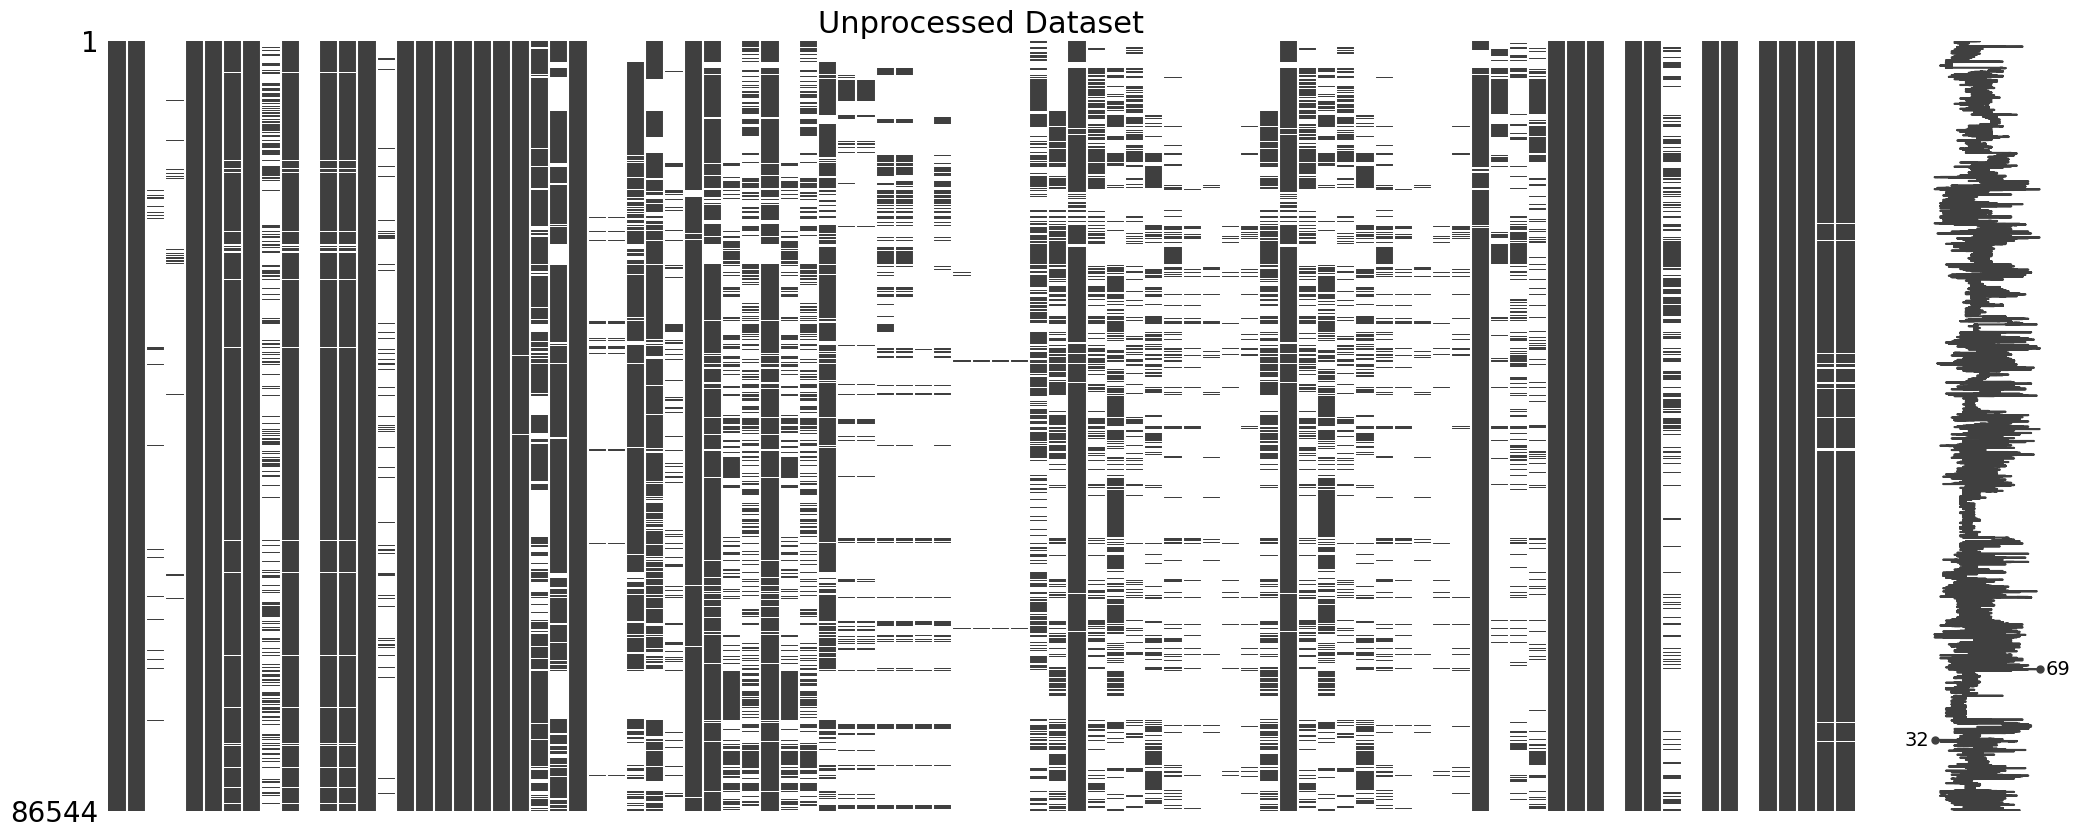

<Figure size 640x480 with 0 Axes>

In [4]:
# Overview of dataset identical to Lab 1

import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline 

# External package: conda install missingno 
import missingno as mn

mn.matrix(df)
plt.title("Unprocessed Dataset",fontsize=22)

plt.figure()
plt.show()

## Cleaning the dataset 
As it is at this stage, the dataset is way too big and complicated for us to analyze in any meaningful way. There are a total of 90 columns for us to analyze, with that much data it would be very difficult for our group to be able to make any specific observations about variable importance in relation to the fossil age. In order to get a better understanding of what useful data we have available to us, we began the project with a Filter Bar Plot to try and weed out any unnecessary variables.

Clearly, there is a lot of unusable data contained in this set. Even at a first glance, many of the columns appear completely empty and will obviously not be useful to us. 

* The first step is to remove attributes that just aren't useful for us
* There are 4 columns that had no entries at all
* 14 duplicate columns
* 2 columns that only had one unique value
* 25 columns that had les than 35% of available data
* 37 identifier columns and columns with string data that was too difficult to analyze, or columns*
* represented by other fields
    * columns with the word comments in it like stratcomments and geogcomments contained string data      *in paragraph form that we could not analyze

We also reviewed the variable we are trying to predict, fossil_age. We realized that the age was an interval value, with a minimum and maximum interval representing the different jurassic periods the fossil could have originated from, but we figured the age of the fossil would be easier to analyze at this stage if it was just a singular value showing approximately how old the fossil is. We took the average of the interval to make a new fossil_age variable, and turned the initial interval into fossil_age_error. This means we are now able to see the exact age of the fossil within a certain margin of error.

In [5]:
# Cleaning identical to Lab 1

def getCol(df, index): return df.iloc[:, index]
def getColName(df, index): return df.columns.values[index]
def getNumRows(df): return df.shape[0]
def getNumCols(df): return df.shape[1]
def getDuplicateCols(df):
    ret = set()
    numCols = getNumCols(df)
    for i in range(numCols):
        col = getCol(df, i)
        for j in range(i + 1, numCols):
            otherCol = getCol(df, j)
            if col.equals(otherCol):
                colName = getColName(df, i)
                otherColName = getColName(df, j)
                #print("Found duplicate pair:", colName, otherColName)
                ret.add(otherColName)
    return list(ret)

def getMissingCols(df, proportion):
    return [col for col in df.columns if df[col].count() <= (proportion * getNumRows(df))]
    
def uniqueCols(df, maxUniqueVals):
    return [col for col in df.columns if len(df[col].unique()) <= maxUniqueVals]

if getNumCols(df) < 91:
    print("We dropped columns already")
else:
    nullCols = getMissingCols(df, 0)
    print("Dropped columns with no values:", nullCols)
    df.drop(columns=nullCols, inplace=True)

    duplicates = getDuplicateCols(df)
    print("Dropped duplicate columns:", duplicates)
    df.drop(columns=duplicates, inplace=True)

    # Note: Threshold has been raised to 35% from 25% since lab 1
    missingCols = getMissingCols(df, 0.25)
    print("Dropped columns with at least 65% not available:", missingCols)
    df.drop(columns=missingCols, inplace=True)

    uniques = uniqueCols(df, 1)
    print("Dropped columns with only 1 unique value:", uniques)
    df.drop(columns=uniques, inplace=True)

    # Normalization
    df['fossil_age'] = (df['max_ma'] + df['min_ma']) / 2
    df['fossil_age_error'] = (df['max_ma'] - df['min_ma']) / 2
    df.drop(columns=['min_ma', 'max_ma'], inplace=True)
    
    #df['altitude_meters'] = np.where(df['altitude_unit'] == 'feet',
    #    0.3048 * df['altitude_value'], df['altitude_value'])
    #df.drop(columns=['altitude_value', 'altitude_unit'], inplace=True)

    df['lithology1'] = np.where(df['lithology1'] == 'not reported', np.nan, df['lithology1'])

    manual_drop = [
        # Identifiers only
        'occurrence_no', 'collection_no', 'identified_no', 'cx_int_no',
        'accepted_no', 'reference_no', 'authorizer_no', 'enterer_no', 'modifier_no',
        'authorizer', 'enterer', 'modifier', 'created', 'modified',
        # Cannot be analyzed for our purposes
        'geogcomments', 'stratcomments', 'geology_comments', 'occurrence_comments',
        'lithdescript', 'protected', 'geoplate', 'lithadj1',
        # These fields were better represented by another field
        'early_interval', 'late_interval', 'latlng_basis', 'latlng_precision',
        'identified_name', 'identified_rank', 'difference',
        'cc', 'state', 'county', 'geogscale',
        'fossilsfrom1', 'formation', 'paleoage',
        #'altitude_meters', 'minor_lithology1'
        # very little unique information, just drop for consistency with Lab 1
        'lithification1',
        ]
    print("Manually selected columns to drop:", manual_drop)
    df.drop(columns=manual_drop, inplace=True, errors = 'ignore')

df.info()

Dropped columns with no values: ['accepted_attr', 'updater_no', 'updater', 'updated']
Dropped duplicate columns: ['lithification1.1', 'minor_lithology2.1', 'lithadj1.1', 'lithology2.1', 'fossilsfrom1.1', 'member.1', 'lithology1.1', 'lithdescript.1', 'minor_lithology1.1', 'lithadj2.1', 'geological_group.1', 'formation.1', 'fossilsfrom2.1', 'lithification2.1']
Dropped columns with at least 65% not available: ['reid_no', 'flags', 'late_interval', 'altitude_value', 'altitude_unit', 'protected', 'zone', 'zone_type', 'localsection', 'localbed', 'localbedunit', 'localorder', 'regionalsection', 'regionalbed', 'regionalbedunit', 'regionalorder', 'minor_lithology1', 'lithology2', 'lithadj2', 'lithification2', 'minor_lithology2', 'fossilsfrom2', 'tectonic_setting', 'geology_comments', 'occurrence_comments']
Dropped columns with only 1 unique value: ['record_type', 'paleomodel']
Manually selected columns to drop: ['occurrence_no', 'collection_no', 'identified_no', 'cx_int_no', 'accepted_no', 'refe

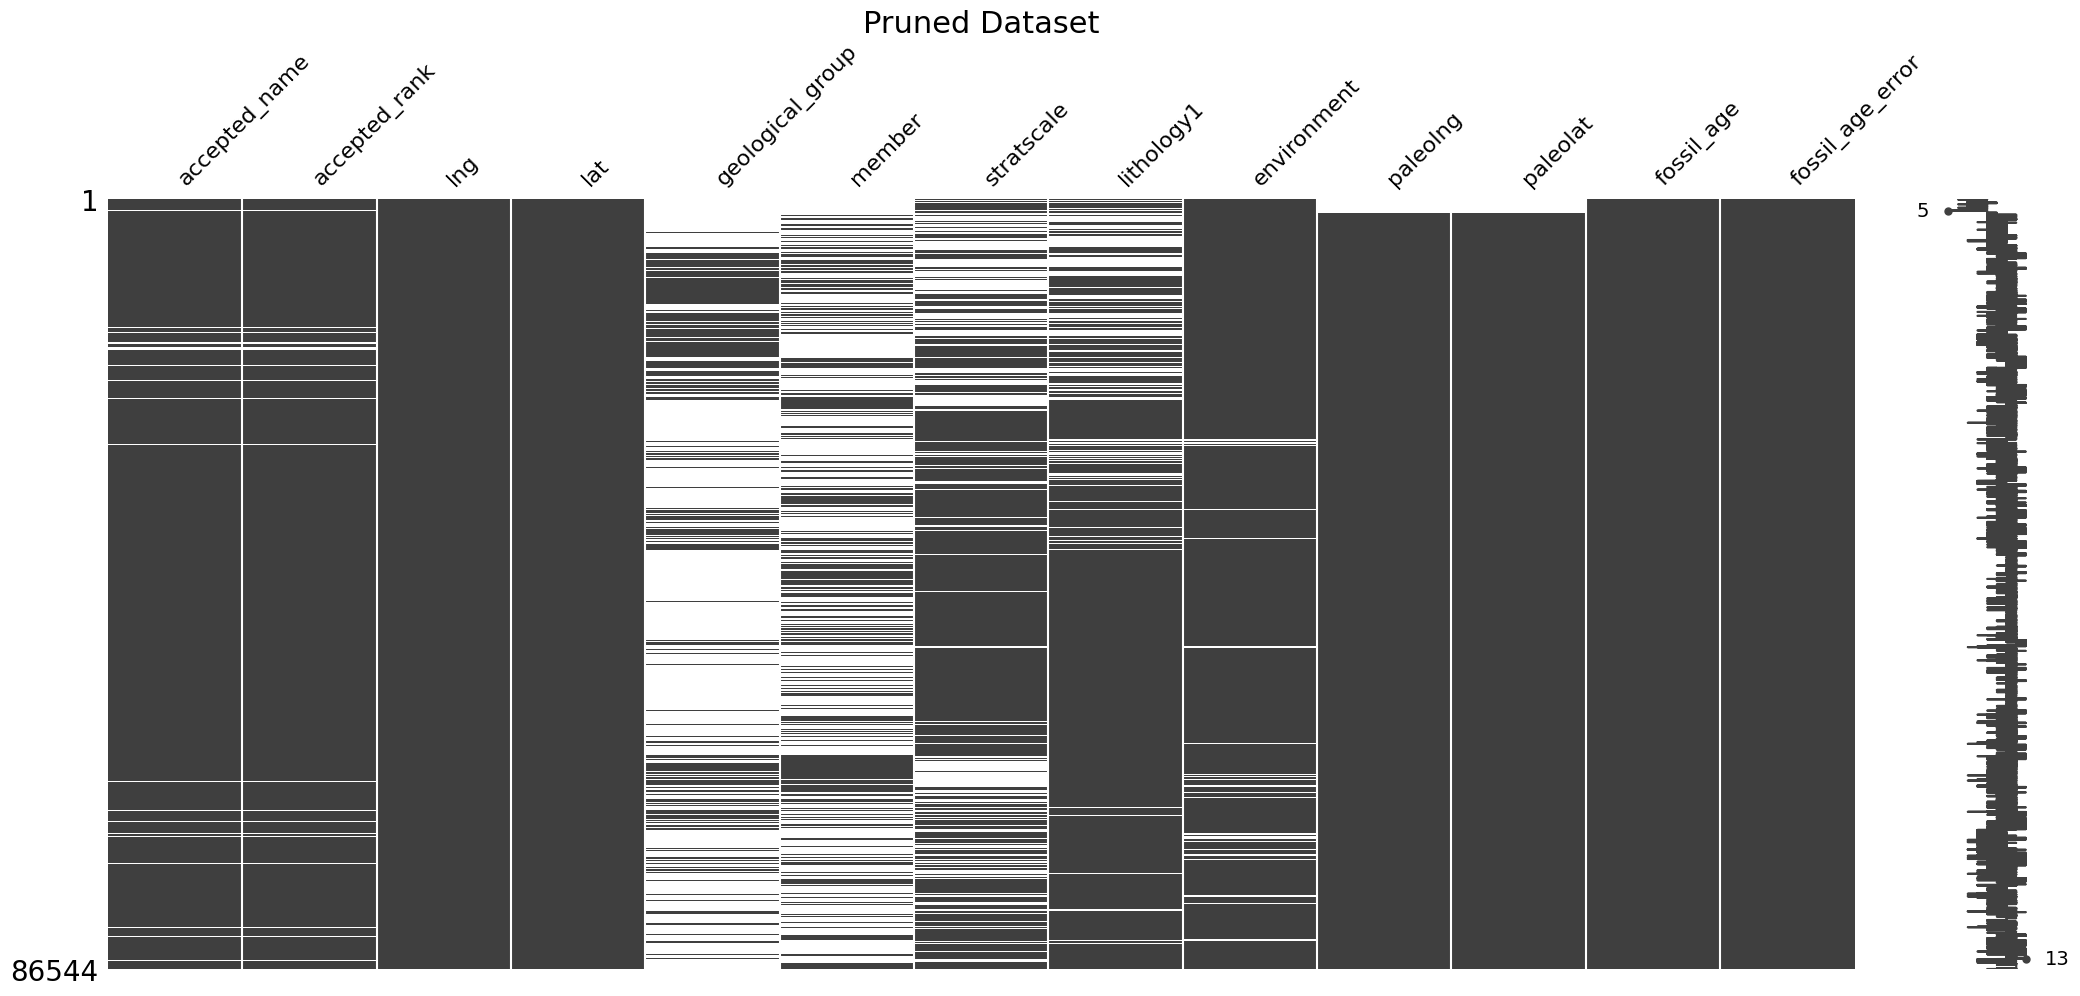

<Figure size 640x480 with 0 Axes>

In [6]:
mn.matrix(df.sort_values(by = ['fossil_age']))
plt.title("Pruned Dataset",fontsize=22)

plt.figure()
plt.show()

In [7]:
df.describe(include='all')

,accepted_name,accepted_rank,lng,lat,geological_group,member,stratscale,lithology1,environment,paleolng,paleolat,fossil_age,fossil_age_error
count,83904,83904,86544.000000,86544.000000,26443,32569,62676,71491,83599,84979.000000,84979.000000,86544.000000,86544.000000
unique,13607,21,NaN,NaN,113,535,5,34,61,NaN,NaN,NaN,NaN
top,Crinoidea,species,NaN,NaN,Claiborne,Finis Shale,group of beds,"""limestone""",marine indet.,NaN,NaN,NaN,NaN
freq,353,44399,NaN,NaN,6699,2773,32869,25534,23517,NaN,NaN,NaN,NaN
mean,NaN,NaN,-99.366563,32.373091,NaN,NaN,NaN,NaN,NaN,-56.133583,15.116353,198.599343,3.765635
std,NaN,NaN,4.211591,2.581681,NaN,NaN,NaN,NaN,NaN,26.408850,21.238584,137.557906,3.339382
min,NaN,NaN,-107.467003,25.366671,NaN,NaN,NaN,NaN,NaN,-134.410000,-37.430000,0.005850,0.005850
25%,NaN,NaN,-103.223999,30.375000,NaN,NaN,NaN,NaN,NaN,-74.480000,-1.850000,63.830000,2.170000
50%,NaN,NaN,-98.177498,31.860001,NaN,NaN,NaN,NaN,NaN,-52.590000,10.580000,265.590000,3.185000
75%,NaN,NaN,-96.472504,34.290001,NaN,NaN,NaN,NaN,NaN,-32.280000,36.380000,301.300000,4.450000


Now, we are left with a much cleaner dataset with only 13 columns.

* accepted_name: name of the dinosaur
* accepted_rank: lowest identified taxonomic rank of the dinosaur (genus, species, etc.)
* lng: longitude fossil was found
* lat: latitude fossil was found
* geological group: stratigraphic group (that is, a group of related rock formations) it was found in
* member: rock formation it was found in
* stratscale: stratigraphy of the fossil, rock layer it was found in
* lithology1: charatceristics of the rock formation
* environment: environment/biome fossil was found in
* paleolng: estimated longitude at the time of the 
* paleolat: estimated lattitude in jurassic times based on techtonic movement
* fossil_age: estimated age of the fossil
* fossil_age_error: estimated margin of error for fossil age
    
However, some of the columns are still missing data which is mostly categorical, making imputation more difficult. We first hashed categorical data to make it easier to work with. We then had to choose a method for imputation. We knew that a split-mean-impute method would not be viable as we are working with categorical data, so we instead chose to use the K-nearest-neighbor method.

In [8]:
# Improvement: Use one-hot encoding for categorial vars

# Make a copy just in case
import copy
df_unencoded = copy.deepcopy(df)

def one_hot_encoder(df, cols):
    for col in cols:
        if col not in df: continue
        tmp_df = pd.get_dummies(df[col], prefix=col)
        df = pd.concat((df,tmp_df),axis=1)
        del df[col]
    return df

# One-hot encode all remaining categorical vars
categorical_vars = ['accepted_name', 'accepted_rank', 'geological_group', 'member',
                          'stratscale', 'lithology1', 'environment']
numeric_vars = list(set(df.columns) - set(categorical_vars))
df = one_hot_encoder(df, categorical_vars)
df.columns = df.columns.str.replace(' ', '_')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86544 entries, 0 to 86543
Columns: 14382 entries, lng to environment_wet_floodplain
dtypes: bool(14376), float64(6)
memory usage: 1.2 GB


In [9]:
# Improvement: Use new imputation method

# Make a copy just in case
df_encoded = copy.deepcopy(df)

# 2. Impute some missing values, grouped by paleolat, paleolng
df_grouped = df.groupby(by=['paleolat', 'paleolng'])

# # now use this grouping to fill the data set in each group, then transform back
# fill in the numeric values
numeric_columns = numeric_vars # only transform numeric columns
df_imputed = df_grouped[numeric_columns].transform(lambda grp: grp.fillna(grp.median()))
df[df_imputed.columns] = df_imputed

# # fillin the grouped variables from original data frame
# df_imputed[['paleolat','paleolng']] = df[['paleolat','paleolng']]

# 4. drop rows that still had missing values after grouped imputation
df.dropna(inplace=True)

# # 5. Rearrange the columns
# #df_imputed = df_imputed[['Survived','Age','Sex','Parch','SibSp','Pclass','Fare','Embarked']]

df[numeric_columns].info()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84979 entries, 0 to 86543
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   lng               84979 non-null  float64
 1   paleolng          84979 non-null  float64
 2   lat               84979 non-null  float64
 3   paleolat          84979 non-null  float64
 4   fossil_age_error  84979 non-null  float64
 5   fossil_age        84979 non-null  float64
dtypes: float64(6)
memory usage: 4.5 MB
<class 'pandas.core.frame.DataFrame'>
Index: 84979 entries, 0 to 86543
Columns: 14382 entries, lng to environment_wet_floodplain
dtypes: bool(14376), float64(6)
memory usage: 1.1 GB


Now that we have imputed the categorical values, we can move forward with the prediction task. 

In [10]:
# Geologic periods:
# Quaternary    2.6 to 0 million years ago
# Neogene 	 	23 to 2.6 million years ago
# Paleogene 	66 to 23 million years ago
# Cretaceous 	143.1 to 66 million years ago
# Jurassic 	 	201.4 to 143.1 million years ago
# Triassic 	 	251.9 to 201.4 million years ago
# ...

# Geologic eras:
# Cenozoic 	 	 	66 to 0 million years ago
# Mesozoic 	 	 	251.9 to 66 million years ago
# Paleozoic 	 	538.8 to 251.9 million years ago
# Neoproterozoic 	1,000 to 538.8 million years ago
# Mesoproterozoic 	1,600 to 1,000 million years ago
# ...

# Split the Mesozoic when dinosaurs live into Cretaceous, Jurassic, Triassic,
# then split Cretaceous into upper and lower since most dinosaurs live here
#
# Cenozoic 	 	 	66 to 0 million years ago
# Upper Cretaceous 	100.5 to 66 million years ago
# Lower Cretaceous 	143.1 to 100.5 million years ago
# Jurassic 	 	 	201.4 to 143.1 million years ago
# Triassic 	 	 	251.9 to 201.4 million years ago
# Paleozoic 	 	538.8 to 251.9 million years ago
# Neoproterozoic 	1,000 to 538.8 million years ago
# Mesoproterozoic 	1,600 to 1,000 million years ago

# create a list of our conditions
if 'fossil_age' in df:
    conditions = [
        (df['fossil_age'] <= 66), 
        (df['fossil_age'] > 66) & (df['fossil_age'] <= 100.5),
        #'Maastrichtian', 'Campanian', 'Santonian - Cetamanian',
        #(df['fossil_age'] > 66) & (df['fossil_age'] <= 72.2),
        #(df['fossil_age'] > 72.2) & (df['fossil_age'] <= 83.6),
        #(df['fossil_age'] > 83.6) & (df['fossil_age'] <= 100.5),
        (df['fossil_age'] > 100.5) & (df['fossil_age'] <= 143.1),
        (df['fossil_age'] > 143.1) & (df['fossil_age'] <= 201.4),
        (df['fossil_age'] > 201.4) & (df['fossil_age'] <= 251.9),
        (df['fossil_age'] > 251.9) & (df['fossil_age'] <= 538.8),
        (df['fossil_age'] > 538.8) & (df['fossil_age'] <= 1000),
        (df['fossil_age'] > 1000) & (df['fossil_age'] <= 1600),
        (df['fossil_age'] > 1600)
        ]
    
    # create a list of the values we want to assign for each condition
    class_names = ['Cenozoic',
                   'Upper Cretaceous', 'Lower Cretaceous', 'Jurassic', 'Triassic',
                   'Paleozoic',
                   'Neoproterozoic', 
                   'Mesoproterozoic',
                   '???']
    class_values = range(len(class_names))
    
    # create a new column and use np.select to assign values to it using our lists as arguments
    def get_target(conditions, values):
        return np.select(conditions, values, default = values[-1])
    
    def unique_describe(col: pd.Series):
        return col.value_counts(dropna=False).reset_index(name="Frequency")
    
    named_target = get_target(conditions, class_names)
    df['target'] = get_target(conditions, class_values)

    # Let's remove our information about the actual answer now
    del df['fossil_age']
    del df['fossil_age_error']

# Ensure df_imputed is an alias of df
df_imputed = df

#describe = unique_describe(pd.Series(named_target))
describe = unique_describe(df['target'])

most_frequent_baseline = describe['Frequency'][0] / sum(describe['Frequency'])
print(most_frequent_baseline)
print(describe)

0.5539015521481778
   target  Frequency
0       5      47070
1       0      21763
2       1      12115
3       2       2830
4       4       1024
5       3        177


To make this prediction task more accurate, we decided to add a layer of classification and divided up the data based on geologic eras. We divided the Mesozoic era when the dinosaurs lived to demonstrate the viability of this method with more specific classifications, and even splitting the Cretaceous period in half as there were many dinosaur species that only lived very close to the extinction event like the T-rex.

* Fossils between 0-66 million years old are in the Cenozoic era.
* The Mesozoic era is divided as follows:
    * The Cretaceous period is divided in two:
        * between 66 million years and 100.5 million years old is the Upper Cretaceous,
        * and between 100.5-143.1 million years old are in the Lower Cretaceous period.
    * Between 143.1–201.4 million years old means the fossil is from the Jurassic period.
    * If the fossil is between 201.4–251.9 million years old, it is from the Triassic period.
* If it is between 251.9–538.8 million years old it is from the Paleozoic era.
* These classifications are not used after imputation, but is kept for reference:
    * if the fossil is between 538.8–1000 million years old it is from the Neoproterozoic period,
    * if it is between 1000–1600 million years old it is from the Mesoproterozoic,
    * and if it is more than 1600 million years old it does not fall into any specific period we are classifying.

This is now the prediction task for the project: classifying fossils into specific geologic periods instead of just an age range, with the different eras being represented by the numbers 0-5. This data also shows us that just classifying every fossil into the most frequent period, the Paleozoic era, would result in a baseline accuracy of 55.4%.

## Classification

In [11]:
# Penalty formula as a reference
"""
class Regularization:
    # Regularization function
    @staticmethod
    def orig(C1, C2, w):
        return C1 * np.abs(w) + C2 * (w ** 2)

    # First derivative
    @staticmethod
    def prime1(C1, C2, w):
        return C1 * np.sign(w) + C2 * 2 * w

    # Second derivative
    @staticmethod
    def prime2(C1, C2, w):
        return 0 + C2 * 2
"""

from scipy.special import expit
# from last time, our logistic regression algorithm is given by (including everything we previously had):
class BinaryLogisticRegression:
    # Default is no regularization, specify C1 and/or C2 to enable L1 and/or L2 regularization, respectively
    def __init__(self, eta, iterations=20, C1=0, C2=0.001):
        self.eta = eta
        self.iters = iterations
        self.C1 = C1 # constant for L1
        self.C2 = C2 # constant for L2
        # internally we will store the weights as self.w_ to keep with sklearn conventions
        
    def __str__(self):
        if(hasattr(self,'w_')):
            return 'Binary Logistic Regression Object with coefficients:\n'+ str(self.w_) # if we have trained the object
        else:
            return 'Untrained Binary Logistic Regression Object'
        
    # convenience, private:
    @staticmethod
    def _add_bias(X):
        return np.hstack((np.ones((X.shape[0],1)),X)) # add bias term
    
    @staticmethod
    def _sigmoid(theta):
        # increase stability, redefine sigmoid operation
        return expit(theta) #1/(1+np.exp(-theta))
    
    # vectorized gradient calculation with regularization
    def _get_gradient(self,X,y):
        ydiff = y-self.predict_proba(X,add_bias=False).ravel() # get y difference
        gradient = np.mean(X * ydiff[:,np.newaxis], axis=0) # make ydiff a column vector and multiply through
        
        gradient = gradient.reshape(self.w_.shape)
        # Regularization first derivative
        gradient[1:] -= (self.C1 * np.sign(self.w_[1:]) + self.C2 * 2 * self.w_[1:])
        
        return gradient

    def _get_direction(self,X,y):
        return self._get_gradient(X,y)
    
    # public:
    def predict_proba(self,X,add_bias=True):
        # add bias term if requested
        Xb = self._add_bias(X) if add_bias else X
        return self._sigmoid(Xb @ self.w_) # return the probability y=1
    
    def predict(self,X):
        return (self.predict_proba(X)>0.5) #return the actual prediction
    
    
    def fit(self, X, y):
        Xb = self._add_bias(X) # add bias term
        num_samples, num_features = Xb.shape
        
        self.w_ = np.zeros((num_features,1)) # init weight vector to zeros
        
        # for as many as the max iterations
        for _ in range(self.iters):
            gradient = self._get_direction(Xb,y)
            self.w_ += gradient*self.eta # multiply by learning rate 
            # add bacause maximizing 

class StochasticLogisticRegression(BinaryLogisticRegression):

    # define custom line search for problem
    def __init__(self, mini_batch_size=32, **kwds):        
        self.mini_batch_size = mini_batch_size
        # but keep other keywords
        super().__init__(**kwds) # call parent initializer
    
    # stochastic "gradient" calculation 
    def _get_direction(self,X,y):
        
        # grab a subset of samples in a mini-batch
        # and calculate the gradient according to the small batch only
        idxs = np.random.choice(len(y), self.mini_batch_size)
        
        return self._get_gradient(X[idxs],y[idxs])

from numpy.linalg import pinv
class HessianBinaryLogisticRegression(BinaryLogisticRegression):
    # just overwrite gradient function
    def _get_direction(self,X,y):
        g = self.predict_proba(X,add_bias=False).ravel() # get sigmoid value for all classes
        # Regularization second derivative used in Hessian calculation
        hessian = X.T @ np.diag(g*(1-g)) @ X - (2 * self.C2)

        gradient = self._get_gradient(X,y)
        
        return pinv(hessian) @ gradient

from scipy.optimize import fmin_bfgs # maybe the most common bfgs algorithm in the world
from numpy import ma
class BFGSBinaryLogisticRegression(BinaryLogisticRegression):
    
    @staticmethod
    def objective_function(w, X, y, C1, C2):
        g = expit(X @ w)
        # invert this because scipy minimizes, but we derived all formulas for maximzing
        return -( ma.sum(ma.log(g[y==1]))-ma.sum(ma.log(1-g[y==0]))  #-np.sum(y*np.log(g)+(1-y)*np.log(1-g))
                  - (C1 * sum(np.abs(w)) + C2 * sum(w ** 2))) # regularization penalty
       
    @staticmethod
    def objective_gradient(w, X, y, C1, C2):
        g = expit(X @ w)
        ydiff = y-g # get y difference
        gradient = np.mean(X * ydiff[:,np.newaxis], axis=0)
        gradient = gradient.reshape(w.shape)
        # first derivative of objective function regularization
        gradient[1:] -= (C1 * np.sign(w[1:]) + C2 * 2 * w[1:])
        return -gradient
    
    # just overwrite fit function
    def fit(self, X, y):
        Xb = self._add_bias(X) # add bias term
        num_samples, num_features = Xb.shape
        
        self.w_ = fmin_bfgs(self.objective_function, # what to optimize
                            np.zeros((num_features,1)), # starting point
                            fprime=self.objective_gradient, # gradient function
                            args=(Xb, y, self.C1, self.C2), # extra args for gradient and objective function
                            gtol=1e-03, # stopping criteria for gradient, |v_k|
                            maxiter=self.iters, # stopping criteria iterations
                            disp=False)
        
        self.w_ = self.w_.reshape((num_features,1))


# allow for the user to specify the algorithm they want to solver the binary case
class MultiClassLogisticRegression:
    def __init__(self, eta, iterations=20, 
                 C1=0, C2=0.001, 
                 solver=BFGSBinaryLogisticRegression):
        self.eta = eta
        self.iters = iterations
        self.C1 = C1
        self.C2 = C2
        self.solver = solver
        self.classifiers_ = []
        # internally we will store the weights as self.w_ to keep with sklearn conventions
    
    def __str__(self):
        if(hasattr(self,'w_')):
            return 'MultiClass Logistic Regression Object with coefficients:\n'+ str(self.w_) # is we have trained the object
        else:
            return 'Untrained MultiClass Logistic Regression Object'
        
    def fit(self,X,y):
        num_samples, num_features = X.shape
        self.unique_ = np.sort(np.unique(y)) # get each unique class value
        num_unique_classes = len(self.unique_)
        self.classifiers_ = []
        for i,yval in enumerate(self.unique_): # for each unique value
            y_binary = np.array(y==yval).astype(int) # create a binary problem
            # train the binary classifier for this class
            
            hblr = self.solver(eta=self.eta, iterations=self.iters, C1=self.C1, C2=self.C2)
            hblr.fit(X,y_binary)

            # add the trained classifier to the list
            self.classifiers_.append(hblr)
            
        # save all the weights into one matrix, separate column for each class
        self.w_ = np.hstack([x.w_ for x in self.classifiers_]).T
        
    def predict_proba(self,X):
        probs = []
        for hblr in self.classifiers_:
            probs.append(hblr.predict_proba(X).reshape((len(X),1))) # get probability for each classifier
        
        return np.hstack(probs) # make into single matrix
    
    def predict(self,X):
        return self.unique_[np.argmax(self.predict_proba(X),axis=1)] # take argmax along row
 

This code is where we created our own logistic regression framework. It includes several different optimization methods to choose from including binary with standard gradient ascent, stochastic, a Hessian-based model, and lastly a BFGS algorithm to approximate the hessian matrix or its inverse, which all have compatability with L1 and L2 regularization (using the cost variables C1 and C2, respectively).

In [12]:
# Get ready to classify

from sklearn.model_selection import ShuffleSplit

# we want to predict the X and y data as follows:
target = 'target'
if target in df_imputed:
    y = df_imputed[target].to_numpy() # get the labels we want
    del df_imputed[target] # get rid of the class label
    
    # Standardization
    norm_features = ['lng', 'lat', 'paleolat', 'paleolng']
    df_imputed[norm_features] = (df_imputed[norm_features]-df_imputed[norm_features].mean()) / df_imputed[norm_features].std()

    # This would run over all the columns:
    #X = df_imputed.to_numpy() # use everything else to predict!
    
    # However, we know there are specific highly correlated columns and it takes a while with so much data...
    X = df_imputed[['paleolat', 'paleolng']].to_numpy() 
    ## X and y are now numpy matrices, by calling 'values' on the pandas data frames we
    #  have converted them into simple matrices to use with scikit learn  

X = X.astype(float)  

This is the code we used to prepare the dataset for the actual classification, we decided to use only the features paleolat and paleolng as they were the features with the most correlation to the age of the fossil, which we learned from the data visualization tasks in lab 1. 

Below is where we applied the regression model. We used the 80% training and 20% testing split. Putting 80% of the data towards training makes sure the model has enough information to learn  patterns, while keeping 20% of the data for testing provides a sample that is still large enough to evaluate performance. The classifier used is configured with a learning rate (eta=0.1), with 10 iterations, and regularization terms (C1=0, C2=0.001).

In [13]:
# Let's classify it!

# to use the cross validation object in scikit learn, we need to grab an instance
#    of the object and set it up. This object will be able to split our data into 
#    training and testing splits
num_cv_iterations = 3
num_instances = len(y)
# Use an 80/20 train/test split
cv_object = ShuffleSplit(n_splits=num_cv_iterations,
                         test_size=0.2)
                         
print(cv_object)

# run logistic regression and vary some parameters
from sklearn import metrics as mt

# first we create a reusable logisitic regression object
#   here we can setup the object with different learning parameters and constants
classifier = MultiClassLogisticRegression(eta=0.001, iterations=500, C1=0, C2=0.001, 
                                          solver=BFGSBinaryLogisticRegression)

# now we can use the cv_object that we setup before to iterate through the 
#    different training and testing sets. Each time we will reuse the logisitic regression 
#    object, but it gets trained on different data each time we use it.

iter_num=0
# the indices are the rows used for training and testing in each iteration
for train_indices, test_indices in cv_object.split(X,y): 
    # I will create new variables here so that it is more obvious what 
    # the code is doing (you can compact this syntax and avoid duplicating memory,
    # but it makes this code less readable)
    X_train = X[train_indices]
    y_train = y[train_indices]
    
    X_test = X[test_indices]
    y_test = y[test_indices]

    print("==== Iteration", iter_num, "====")
    
    # train the reusable logistic regression model on the training data
    %time classifier.fit(X_train,y_train)  # train object
    %time y_hat = classifier.predict(X_test) # get test set precitions

    # now let's get the accuracy and confusion matrix for this iterations of training/testing
    acc = mt.accuracy_score(y_test,y_hat)
    conf = mt.confusion_matrix(y_test,y_hat)
    
    print("accuracy", acc )
    print("confusion matrix\n",conf)
    iter_num += 1
    
# Also note that every time you run the above code
#   it randomly creates a new training and testing set, 
#   so accuracy will be different each time

ShuffleSplit(n_splits=3, random_state=None, test_size=0.2, train_size=None)
==== Iteration 0 ====
CPU times: user 1.45 s, sys: 537 ms, total: 1.98 s
Wall time: 1.69 s
CPU times: user 1.65 ms, sys: 555 μs, total: 2.2 ms
Wall time: 1.91 ms
accuracy 0.8065427159331607
confusion matrix
 [[4353    0    0    0    0    0]
 [2454    0    0    0    0    0]
 [ 587    0    0    0    0    0]
 [  25    0    0    0    0    5]
 [   0    0    0    0    0  211]
 [   6    0    0    0    0 9355]]
==== Iteration 1 ====
CPU times: user 1.67 s, sys: 577 ms, total: 2.25 s
Wall time: 2.21 s
CPU times: user 1.64 ms, sys: 831 μs, total: 2.48 ms
Wall time: 2.23 ms
accuracy 0.8086020240056484
confusion matrix
 [[4327    0    0    0    0    0]
 [2427    0    0    0    0    0]
 [ 568    0    0    0    0    0]
 [  26    0    0    0    0    2]
 [   0    0    0    0    0  216]
 [  14    0    0    0    0 9416]]
==== Iteration 2 ====
CPU times: user 1.43 s, sys: 471 ms, total: 1.9 s
Wall time: 1.61 s
CPU times: user 1.5

This output shows the results from running the logistic regression model. The CPU and wall times show that training takes a long time, 1.3 seconds per iteration, while testing is very fast. The accuracy is consistently about 80%, which shows consistent performance for our model above our floor accuracy goal of 75%.

So far, our regression looks good and is performing at an accuracy rate, but we want to try and optimize the regularization terms to achieve the best performance possible.

In [14]:
%%time

# Things should be looking promising above when you reach this point.
# Let's do the same thing but maybe we can fine-tune the C2 hyperparameter?

# We're going to experiment holding learning rate to 0.001 and iterations to 10.
# Our accuracy is looking good already but you could fine-tune those too

num_cv_iterations = 20
num_instances = len(y)
cv_object = ShuffleSplit(n_splits = num_cv_iterations,
                         test_size = 0.5)

# Actual exploration code, this iterates num_cv_iterations times to predict and compute accuracy
def explore_single_cost(cost):
    classifier = MultiClassLogisticRegression(eta=0.001, iterations=10, C1=0, C2=float(cost),
                                              solver=BFGSBinaryLogisticRegression)
    acc = []
    for iter_num, (train_indices, test_indices) in enumerate(cv_object.split(X,y)):
        classifier.fit(X[train_indices],y[train_indices])  # train object
        y_hat = classifier.predict(X[test_indices]) # get test set predictions
        acc.append(mt.accuracy_score(y[test_indices],y_hat))
        
    acc = np.array(acc)
    return acc

# descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max)
def describe(arr):
    return pd.DataFrame(arr).describe().T

# This calls explore_single_cost for each of num_costs
# logarithmically spaced cost between 10^(log10_min) to 10^(log10_max)
def explore_multiple_costs(log10_min, log10_max, num_costs):
    global costs, accs
    costs = np.logspace(log10_min, log10_max, num_costs)
    accs = []
    for i, c in enumerate(costs):
        print("Starting iteration", i + 1, "of", num_costs, "for cost", c)
        j = explore_single_cost(c)
        print(describe(j))
        accs.append(j)

# Perform the iterations!
explore_multiple_costs(-5, 1, 20)

Starting iteration 1 of 20 for cost 1e-05
   count      mean       std       min       25%       50%       75%       max
0   20.0  0.809248  0.001275  0.806872  0.808502  0.809449  0.809896  0.812026
Starting iteration 2 of 20 for cost 2.06913808111479e-05
   count      mean       std       min       25%       50%       75%       max
0   20.0  0.808594  0.001526  0.805531  0.807737  0.808555  0.809626  0.810944
Starting iteration 3 of 20 for cost 4.281332398719396e-05
   count      mean       std       min      25%       50%       75%       max
0   20.0  0.809487  0.001425  0.805366  0.80889  0.809461  0.810708  0.811462
Starting iteration 4 of 20 for cost 8.858667904100833e-05
   count      mean       std       min      25%       50%       75%       max
0   20.0  0.809527  0.001354  0.806166  0.80859  0.809614  0.810326  0.811626
Starting iteration 5 of 20 for cost 0.00018329807108324357
   count      mean     std       min       25%       50%       75%       max
0   20.0  0.809725  0

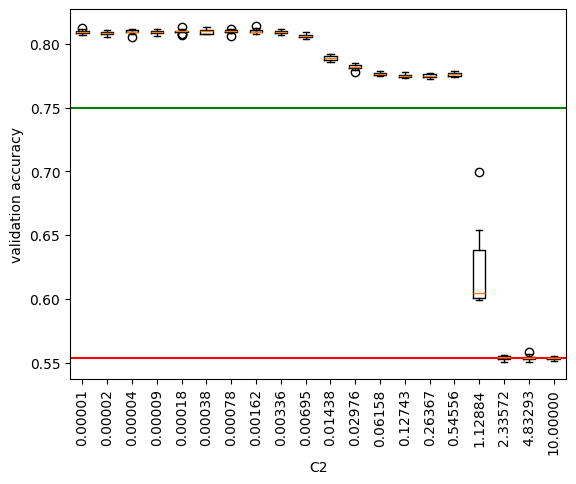

Yellow line is at accuracy 0.8091541539185689


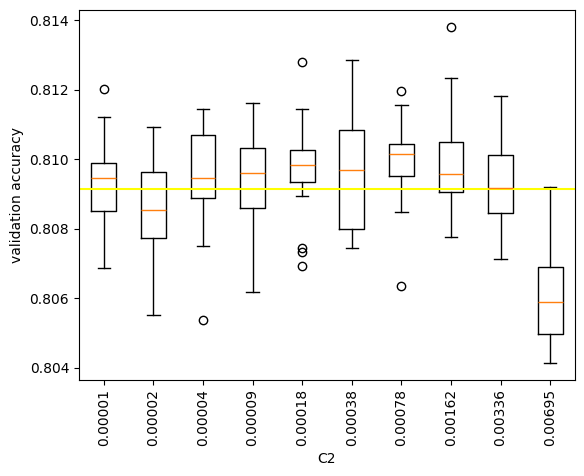

In [15]:
# Show the above data graphically with box plots
from matplotlib import pyplot as plt
%matplotlib inline

plt.boxplot(accs)
plt.xticks(range(1,len(costs)+1), ['%.5f'%(c) for c in costs], rotation='vertical')
plt.xlabel('C2')
plt.ylabel('validation accuracy')
plt.axhline(most_frequent_baseline, c='red') # baseline
plt.axhline(0.75, c='green') # target performance
plt.show()

_costs = costs[0:10]
_accs = accs[0:10]
_mean = np.mean(_accs)
print("Yellow line is at accuracy", _mean)
plt.boxplot(_accs)
plt.xticks(range(1,len(_costs)+1), ['%.5f'%(c) for c in _costs], rotation='vertical')
plt.xlabel('C2')
plt.ylabel('validation accuracy')
plt.axhline(_mean, c='yellow') # mean
plt.show()

To select the parameters we only used data and cross-validation splits without using the test sets to tune these values, avoiding data snooping. The output above is a graphical representation of our testing for the regularization cost across 20 iterations. For each cost value, the model was trained and evaluated 20 times, and the summary statistics of accuracy were recorded. We see that for very small costs, our model has consistent and high accuracy around 0.809–0.810. As C2 grows, the accuracy drops at an exponential rate. C2=.00002 is the best value for our model with a mean accuracy around 81%, above our lowest acceptable accuracy, with a small spread and no outliers.

In [16]:
%%time
# how do we compare now to sklearn?
from sklearn.linear_model import LogisticRegression

iter_num = 0

skaccs = []
C2 = 0.001

for train_indices, test_indices in cv_object.split(X,y): 
    # I will create new variables here so that it is more obvious what 
    # the code is doing (you can compact this syntax and avoid duplicating memory,
    # but it makes this code less readable)
    X_train = X[train_indices]
    y_train = y[train_indices]
    
    X_test = X[test_indices]
    y_test = y[test_indices]

    print("==== Iteration", iter_num, "====")

    lr_sk = LogisticRegression(solver='lbfgs', n_jobs=1, C = 1/C2, penalty='l2', max_iter=500)
    # note that sklearn is optimized for using the liblinear library with logistic regression
    # ...and its faster than our implementation here
    
    lr_sk.fit(X_train, y_train) # no need to add bias term, sklearn does it internally!!
    print(lr_sk.coef_)
    yhat = lr_sk.predict(X_test)
    acc = mt.accuracy_score(y_test, yhat)
    print('Accuracy of: ', acc)
    skaccs.append(acc)

    iter_num += 1

==== Iteration 0 ====
[[ 15.85626356 -11.16832473]
 [ 22.2610182    1.33679939]
 [ 18.91905532  18.1228991 ]
 [ -3.57002326   4.27083495]
 [-23.06347741  -5.43606229]
 [-30.40283641  -7.12614642]]
Accuracy of:  0.9287597081666275
==== Iteration 1 ====
[[ 15.35819912 -10.76419366]
 [ 21.66113381   1.6454549 ]
 [ 19.76385046  18.28021063]
 [ -4.78576644   3.21842576]
 [-22.29491426  -5.33037998]
 [-29.7025027   -7.04951766]]
Accuracy of:  0.9287361732172276
==== Iteration 2 ====
[[ 13.64752507 -10.33709051]
 [ 19.80033953   1.70066622]
 [ 18.77511769  17.36860761]
 [ -2.65794613   3.94641202]
 [-21.0195365   -5.47989952]
 [-28.54549965  -7.19869582]]
Accuracy of:  0.9284772887738292
==== Iteration 3 ====
[[ 14.31322722 -10.95550009]
 [ 20.61257671   1.57079537]
 [ 18.6996695   18.02827707]
 [ -2.78841511   4.35600564]
 [-21.85069294  -5.65835104]
 [-28.98636537  -7.34122696]]
Accuracy of:  0.9274652859496352
==== Iteration 4 ====
[[ 18.994409   -10.34072182]
 [ 25.46977429   2.26484787]


Text(0.5, 1.0, 'Scikit learn classifier')

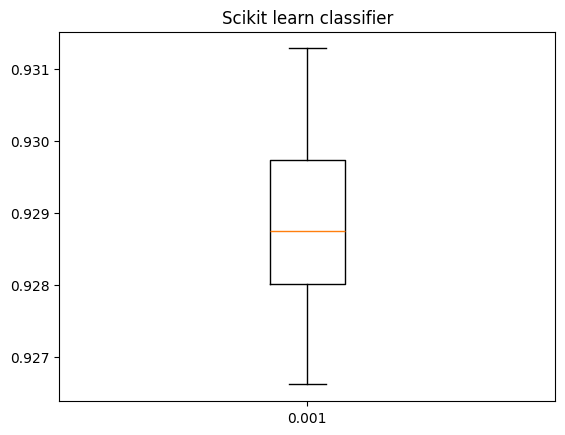

In [17]:
plt.boxplot(skaccs)
plt.xticks([1], [C2])
plt.title('Scikit learn classifier')

We ran the exact same test for the scikit learn model as we did for the classifier we created. As we can clearly see from the graph, the scikit learn model performed much better with its "best" result being an average of around a 92.9% accuracy, with even the lowest accuracy outlier still at 92.6%, even using the same hyperparameters as our initial 3 iterations. Our implementation does exceed our preferred baseline of at least 75% accuracy, but we believe that as the scikit learn model has undergone years of algorithmic refinement, there are undoubtedly optimizations that allows it to perform better than our custom model under the same conditions. Our custom model performs at an accuracy rate above the minimum we required, but established libraries like `scikit-learn` still outperform it and are often much more reliable.